# Figure 4 — resurrected carbonic anhydrases

Redraws the panels of this figure from the released data. Each cell runs a released producer
and shows its output.

Most cells are **level 1**: they redraw a panel from a table shipped in the Zenodo deposit — no
model, no GPU, seconds on a laptop. A few panels have no replot path and need a larger archive,
a checkpoint or a GPU; those cells say so, and `notebooks/README.md` carries the panel-by-panel
table.

Run from the `peint-paper` repository, or set `PEINT_PAPER_REPO` to point at it.

In [1]:
import os, sys, subprocess, pathlib, shutil, tempfile, hashlib
# Locate the peint-paper checkout by looking for its marker files, walking up from the
# working directory. Do NOT resolve a relative ".." here: this cell chdirs to PAPER_REPO
# below, so a relative default would climb one directory on every re-run -- and re-running a
# setup cell is the most ordinary thing anyone does in a notebook. Searching for the marker
# is idempotent: once cwd is the repo root, the root is what the search finds.
def _find_paper_repo():
    env = os.environ.get("PEINT_PAPER_REPO")
    if env:
        return pathlib.Path(env).resolve()
    here = pathlib.Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "paper_config.py").exists() and (d / "figures").is_dir():
            return d
    # beside it: this notebook may have been copied somewhere outside the repository, so
    # also look for a checkout hanging off any ancestor
    for d in (here, *here.parents):
        for cand in (d / "repos" / "peint-paper", d / "peint-paper"):
            if (cand / "paper_config.py").exists() and (cand / "figures").is_dir():
                return cand
    raise RuntimeError(
        "Could not find the peint-paper checkout from " + str(here) +
        ". Set PEINT_PAPER_REPO to the repository root, or run this notebook from inside it."
    )

PAPER_REPO = _find_paper_repo()
os.environ.setdefault("PEINT_PAPER_PEINT_REPO", str(PAPER_REPO.parent / "peint"))
os.environ["PEINT_PAPER_LOCAL_DATA_ONLY"] = "1"
os.chdir(PAPER_REPO)
sys.path.insert(0, str(PAPER_REPO))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Inline display needs IPython. These notebooks are also executed headlessly in CI, where it is
# absent, so fall back to printing rather than failing the whole notebook on the import.
try:
    from IPython.display import display, Image
    _INLINE = True
except ImportError:
    _INLINE = False
    def display(x): print(x)
    def Image(filename=None, width=None): return f"[figure written to {filename}]"

# When the current batch of producers started. A cell may call run() several times before a
# single show(); comparing against the LAST run would falsely flag whatever the earlier runs
# wrote. The timestamp is set by the first run() of a batch and cleared by show(), so the
# question asked is "did this panel appear during this cell", not "during the latest command".
#
# The third slot records which cell opened the batch. Without it, a cell that only calls
# show() -- its producer commented out, as in Fig 2c -- compares its panels against the
# PREVIOUS cell's run and reports every one of them as not rewritten.
_last_run = [0.0, False, None]   # [batch start, batch open, cell that opened it]

def _cell_marker():
    """Identify the cell now executing; None when there is no notebook frontend."""
    try:
        from IPython import get_ipython
    except ImportError:
        return None
    ip = get_ipython()
    return getattr(ip, "execution_count", None) if ip is not None else None

def run(module, *args):
    """Run a panel producer and show its output."""
    import time
    cmd = [sys.executable, "-m", module, *args]
    print("$", " ".join(cmd[2:]))
    if not _last_run[1]:
        _last_run[0], _last_run[1], _last_run[2] = time.time(), True, _cell_marker()
    r = subprocess.run(cmd, capture_output=True, text=True)
    tail = [l for l in r.stdout.split("\n") if l.strip()][-15:]
    print("\n".join(tail))
    if r.returncode:
        print(f"\n  *** FAILED (exit {r.returncode}) ***")
        print("  " + r.stderr.strip().split("\n")[-1][:400])
    return r.returncode == 0

_PREVIEW_DIR = pathlib.Path(tempfile.mkdtemp(prefix="peint_panel_preview_"))

def _rasterize(pdf):
    """Render page 1 of a PDF to a PNG so it can be shown inline; None if nothing here can.

    Several panels -- all of Figure 4 -- are only ever written as PDF. The PDF stays the
    artifact of record: this is a throwaway display copy in a scratch dir, redone whenever the
    PDF is newer than it.
    """
    pdf = pathlib.Path(pdf)
    png = _PREVIEW_DIR / (hashlib.md5(str(pdf).encode()).hexdigest()[:10] + ".png")
    if png.exists() and png.stat().st_mtime >= pdf.stat().st_mtime:
        return png
    try:
        import fitz                                   # PyMuPDF, if it happens to be installed
        fitz.open(pdf)[0].get_pixmap(dpi=200).save(png)
        return png
    except Exception:
        pass
    stem = str(png.with_suffix(""))
    for cmd in (["pdftoppm", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["pdftocairo", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["convert", "-density", "200", str(pdf) + "[0]", "-flatten", str(png)]):
        if not shutil.which(cmd[0]):
            continue
        if subprocess.run(cmd, capture_output=True).returncode == 0 and png.exists():
            return png
    return None

def _show_file(p, w=760, check_stale=True):
    """Show one panel file inline: a PNG as-is, a PDF through a rasterized display copy.

    ``check_stale=False`` is for panels committed to the repository that this notebook cannot
    regenerate (Fig 4a/4b/4d) -- there the mtime says nothing, so the check is waived at the
    call site rather than quietly skipped.
    """
    p = pathlib.Path(p)
    if check_stale and p.stat().st_mtime < _last_run[0]:
        print(f"  NOTE: {p.name} was not rewritten by the command above -- the file on "
              f"disk predates this run. The panel shown below is from an earlier run, so it "
              f"may not correspond to the command just executed.")
    img = p if p.suffix == ".png" else _rasterize(p)
    if img is None:
        print(f"  {p.name} written, but no PDF rasterizer (poppler's pdftoppm, or PyMuPDF) "
              f"is installed to show it inline")
        return
    width = w
    try:                                              # never upscale a small panel to w px
        from PIL import Image as _PILImage
        with _PILImage.open(img) as im:
            width = min(w, im.width)
    except Exception:
        pass
    display(Image(filename=str(img), width=width))

def show(*names, w=760, check_stale=True):
    """Display panel images inline, by name relative to figures/.

    A bare name is looked up in figures/output/ ("figure3_conservation_lg_s256"); a name with a
    subdirectory anywhere under figures/ ("spearman_agg/spearman_plot_esm_150m"). The extension
    is optional -- the PNG is preferred, and a PDF-only panel is rasterized rather than merely
    reported, so every panel can be held up against the printed figure.

    A panel file older than the producer call above it is left over from an earlier run --
    displaying it silently would show you a figure that does not match the code you just ran,
    so say so rather than pretending it is fresh.
    """
    # Only say a panel was not rewritten if a producer ran in THIS cell. A show-only cell has
    # no run of its own to compare against. Where the cell cannot be identified (no IPython,
    # as under scripts/run_notebook.py) fall back to the batch flag, i.e. prior behaviour.
    _marker = _cell_marker()
    ran_here = _last_run[1] if _marker is None else (_last_run[2] == _marker)
    _last_run[1] = False          # close the batch: a later run() starts a new one
    figs = PAPER_REPO / "figures"
    for n in names:
        for p in (figs / f"{n}.png", figs / f"{n}.pdf",
                  figs / "output" / f"{n}.png", figs / "output" / f"{n}.pdf", figs / n):
            if p.exists() and p.suffix in (".png", ".pdf"):
                _show_file(p, w, check_stale and ran_here)
                break
        else:
            print("  not found:", n)

def table(name):
    """Read a released table by name, wherever it lives.

    A producer writes into figures/output; the release ships the same table under
    local_data/figure_data. Look in the released location first so a fresh checkout works
    without having run anything, then fall back to a freshly produced copy.
    """
    for d in (PAPER_REPO / "local_data" / "figure_data",
              PAPER_REPO / "data" / "catjac",
              PAPER_REPO / "figures" / "output"):
        p = d / name
        if p.exists():
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"{name} not found in local_data/figure_data, data/catjac or figures/output. "
        f"Fetch the figure_data tier."
    )


def compare(label, computed, printed, tol=0.05):
    """Print the value this notebook computed beside the one in the manuscript."""
    ok = "MATCH" if abs(computed - printed) <= tol else "CHECK"
    print(f"  {label:<28} computed {computed:>8.3f}   manuscript {printed:>8.3f}   {ok}")

## Where these panels come from

Figure 4 is the wet-lab figure, and the one part of the paper whose panels live in
notebooks committed to the repository under `figures/carbonic_anhydrase_figure/`.
**Every input is in the repository too** — the trees, the stopped-flow traces and the
plate-reader data are all committed, nothing is downloaded, so these are level 1.

| panel | notebook | status |
|---|---|---|
| 4a, 4b tree and structures | `computational/tree_analysis.ipynb` | runs (needs `PyQt5`) |
| 4c pLDDT vs distance | `computational/tree_analysis.ipynb` | runs |
| 4d growth curves | `in_vivo/Experimental.ipynb` | **blocked**, see below |
| 4e stopped-flow kinetics | `in_vitro/stopped_flow_analysis.ipynb` | runs |
| 4f natural kcat distribution | `computational/Brenda_CA.ipynb` | runs |

Panels are written beside their notebooks rather than into `figures/output/`.

In [2]:
NB = PAPER_REPO / "figures" / "carbonic_anhydrase_figure"

# ete3 renders trees through Qt. There is no display on a compute node, so ask Qt for its
# offscreen backend; without this the tree cells abort and 4a/4b never draw.
os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")

# Fig 4d fits growth curves with tecantaloupe, which needs pandas < 2 and so cannot live
# in this environment. It runs in its own, addressed the same way render_panels.py
# addresses the ESM-C environment: point PEINT_PAPER_PY_FIG4D at that interpreter and
# TECANTALOUPE_DIR at a clone of the helper. installation.md has both.
PY_FIG4D = os.environ.get("PEINT_PAPER_PY_FIG4D")

def run_nb(rel, *extra, py=None):
    """Execute a committed notebook's code cells as a script.

    py: an explicit interpreter, for a producer whose dependencies cannot be installed
    alongside this notebook's. Defaults to the interpreter running this notebook.
    """
    import time
    if py is None:
        return run("scripts.run_notebook", str(NB / rel), *extra)
    cmd = [py, "scripts/run_notebook.py", str(NB / rel), *extra]
    print("$", " ".join(cmd[1:]))
    if not _last_run[1]:
        _last_run[0], _last_run[1], _last_run[2] = time.time(), True, _cell_marker()
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=PAPER_REPO)
    tail = [l for l in r.stdout.split("\n") if l.strip()][-15:]
    print("\n".join(tail))
    if r.returncode:
        print(f"\n  *** FAILED (exit {r.returncode}) ***")
        print("  " + r.stderr.strip().split("\n")[-1][:400])
    return r.returncode == 0

def show_ca(*rels, w=760, check_stale=True):
    """Figure 4 panels are written beside their notebooks, not into figures/output.

    Routes through _show_file so the staleness guard applies here too, and so PDFs
    rasterize for inline display. Pass check_stale=False only for a committed panel this
    notebook cannot regenerate, where the mtime means nothing.
    """
    _last_run[1] = False
    for rel in rels:
        p = NB / rel
        if p.exists(): _show_file(p, w, check_stale)
        else: print(f"  not found: {rel}")

## 4a, 4b — the carbonic anhydrase tree

`tree_analysis.ipynb` draws the annotated tree and the per-node structure panels. It needs
**PyQt5** (`pip install PyQt5`), which the published environment recipe omits, plus the
offscreen Qt backend set in the cell above. With both, it runs headless with no failures.

$ scripts.run_notebook figures/carbonic_anhydrase_figure/computational/tree_analysis.ipynb


=== cell 7 ===
{'seq914': False, 'seq1729': False}
=== cell 8 ===
=== cell 9 ===
=== cell 10 ===
=== cell 11 ===
=== cell 12 ===
=== cell 13 ===
After filtering there are 44 leaves in the peint data
After filtering there are 44 leaves in the lg data
=== cell 14 ===
=== cell 15 ===
['seq1738', 'seq1904', 'seq1729', 'seq1789', 'seq1670', 'seq1731', 'seq1944', 'seq1802', 'seq2148', 'seq1834', 'seq376', 'seq1251', 'seq771', 'seq1287', 'seq1436', 'seq1363', 'seq1496', 'seq1513', 'seq1420', 'seq1360']
=== cell 16 ===
notebook complete (failed cells: none)


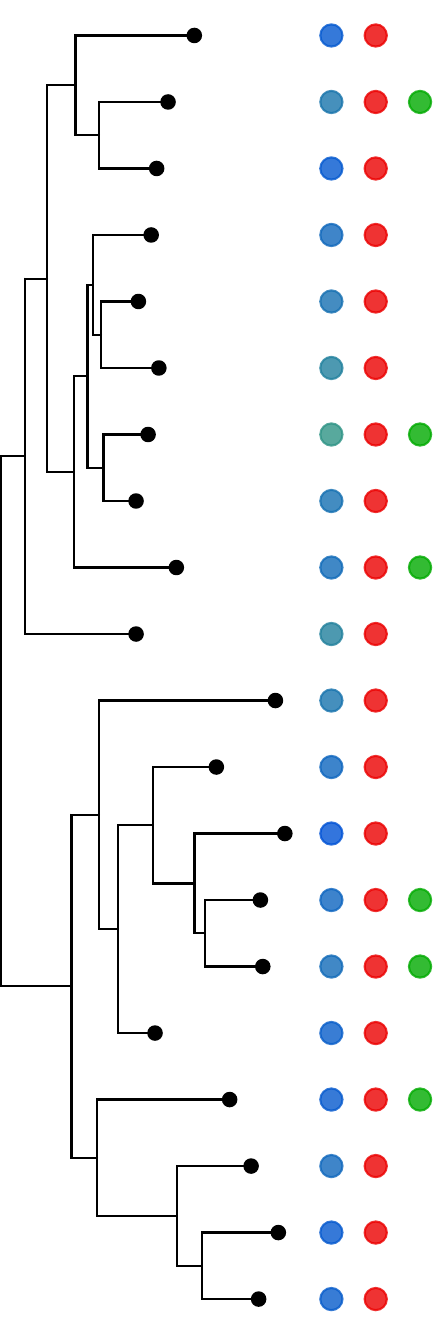

In [3]:
run_nb("computational/tree_analysis.ipynb")
show_ca("computational/figures/tree_summary.pdf")

## 4c — predicted pLDDT vs phylogenetic distance

Produced by the same notebook as 4a/4b, so it has already run in the cell above.

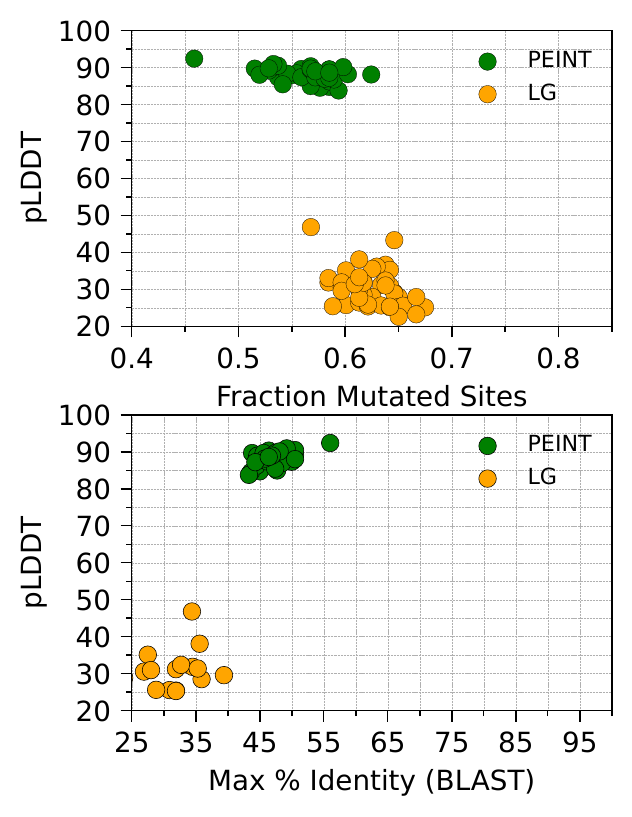

In [4]:
show_ca("computational/figures/bca_plddt_vs_tree_dist_and_pid.pdf")

## 4d — in-vivo growth curves

The inputs are here and complete: `in_vivo/20250220_plate_spec.csv` (the plate layout) and
`in_vivo/20250220_Results_Autosave.xlsx` (the Tecan M1000 export), both committed to the
repository, and `in_vivo/Experimental.ipynb` fits them into the panel.

The fitting itself is done by **tecantaloupe**, which is not on PyPI and is not vendored
here. Clone it and point `TECANTALOUPE_DIR` at the checkout:

```
git clone https://github.com/flamholz/tecantaloupe
git -C tecantaloupe checkout 8199fbb48e4764f96c172de7009dc70c229ae4e6
```

It needs `pandas < 2` (it calls `DataFrame.iteritems`, removed in pandas 2.0), so it gets
its own small environment rather than a change to this one. Set `PEINT_PAPER_PY_FIG4D` to
that interpreter; `installation.md` gives the pinned versions. With both set, the command reruns the
fits and redraws the panel, about fifteen seconds. If the notebook subprocess encounters a
matplotlib backend error, run the same command from a terminal. Without them it shows the
committed panel and says so.

$ scripts/run_notebook.py figures/carbonic_anhydrase_figure/in_vivo/Experimental.ipynb


=== cell 5 ===
=== cell 6 ===
=== cell 7 ===
=== cell 8 ===
=== cell 9 ===
=== cell 10 ===
(0.4, 0.7607843137254902, 0.6470588235294118)
(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)
(0.5529411764705883, 0.6274509803921569, 0.796078431372549)
(0.9058823529411765, 0.5411764705882353, 0.7647058823529411)
(0.6509803921568628, 0.8470588235294118, 0.32941176470588235)
(1.0, 0.8509803921568627, 0.1843137254901961)
(0.8980392156862745, 0.7686274509803922, 0.5803921568627451)
(0.7019607843137254, 0.7019607843137254, 0.7019607843137254)
notebook complete (failed cells: none)


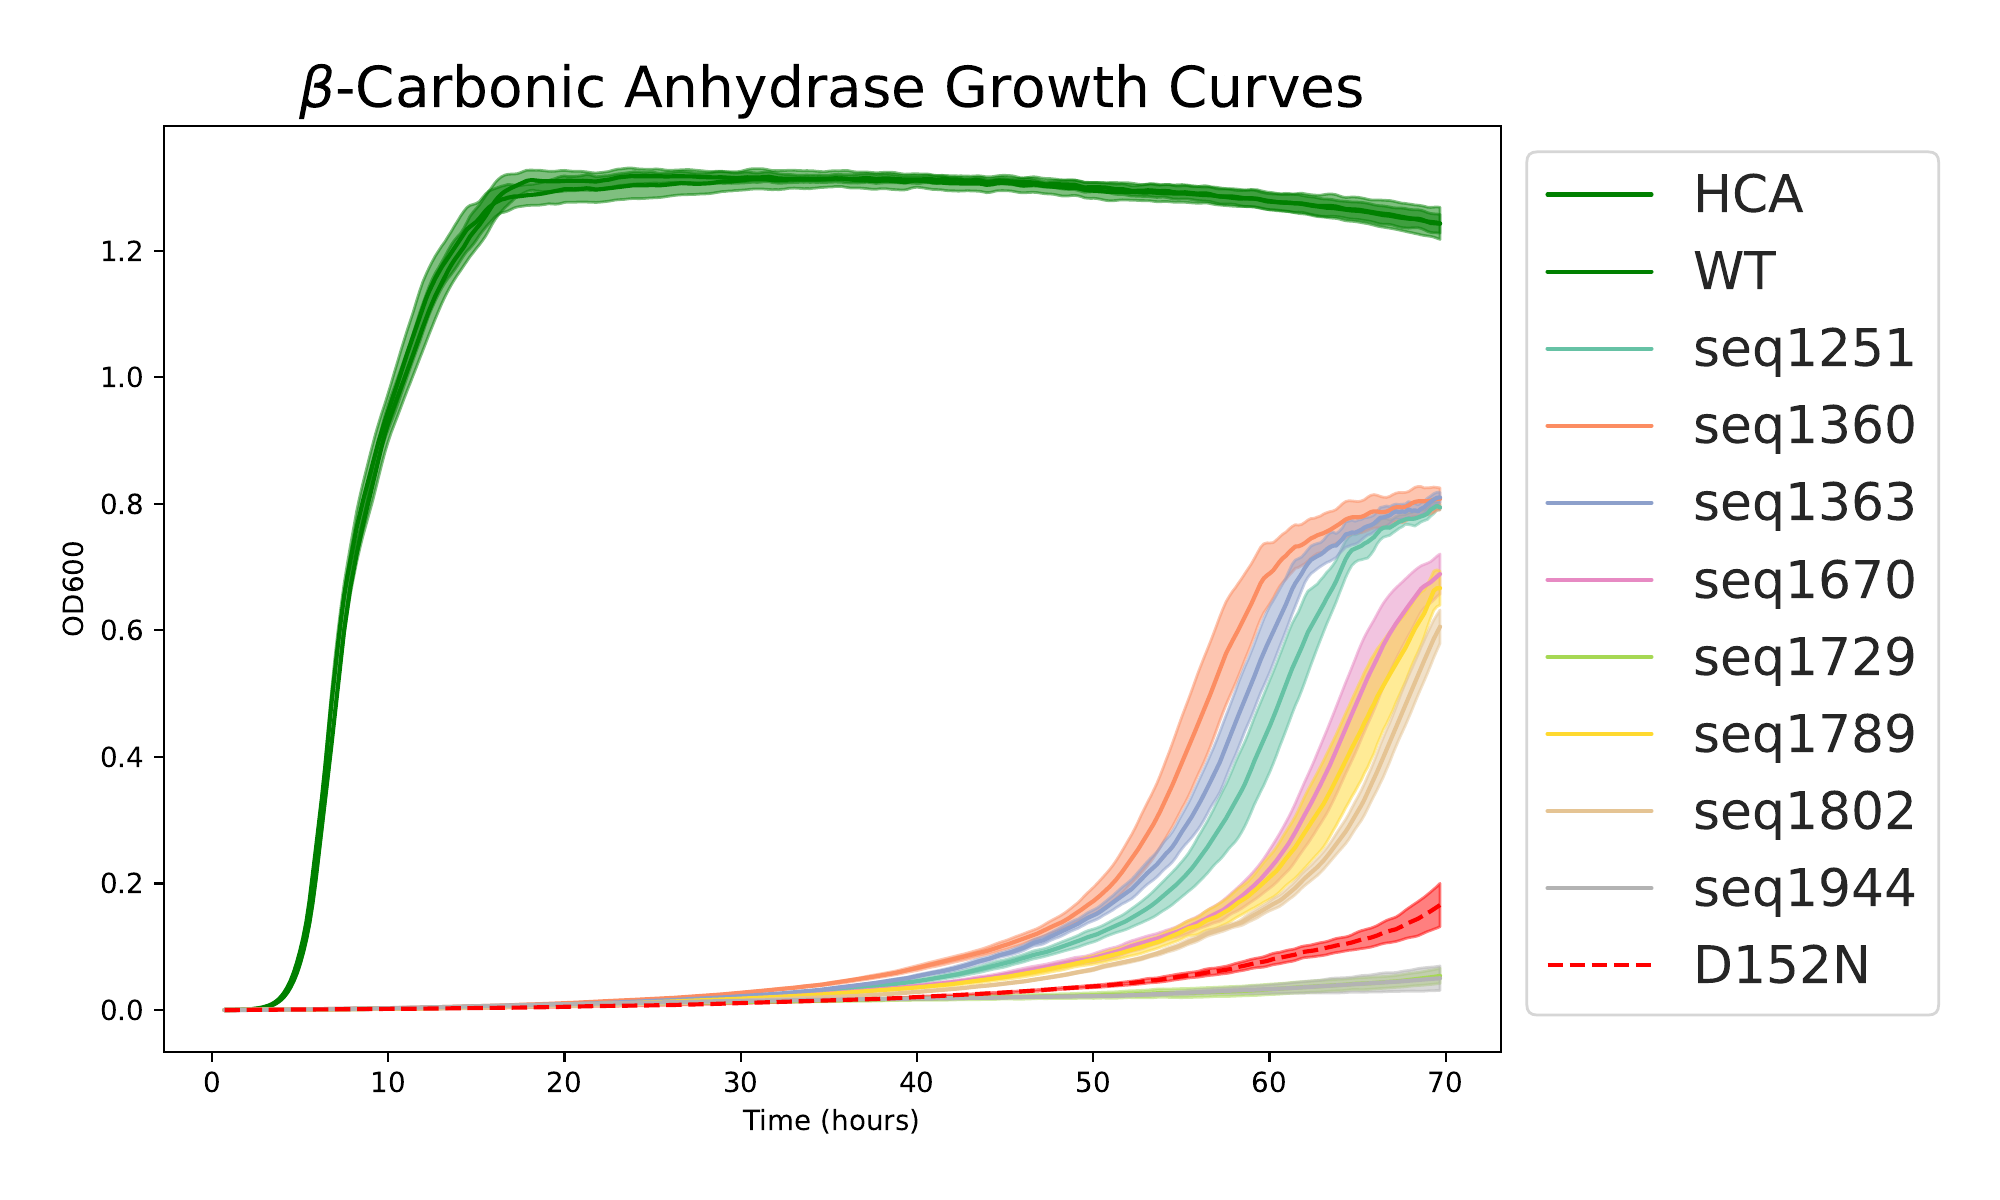

In [5]:
if PY_FIG4D:
    run_nb("in_vivo/Experimental.ipynb", py=PY_FIG4D)
    show_ca("in_vivo/Growth_Curves.pdf")
else:
    print("  PEINT_PAPER_PY_FIG4D is not set - showing the committed panel.")
    print("  installation.md has the clone and the environment for this panel.")
    show_ca("in_vivo/Growth_Curves.pdf", check_stale=False)

## 4e — stopped-flow kinetics

$ scripts.run_notebook figures/carbonic_anhydrase_figure/in_vitro/stopped_flow_analysis.ipynb


=== cell 1 ===
=== cell 3 ===
=== cell 4 ===
=== cell 6 ===
=== cell 7 ===
=== cell 8 ===
notebook complete (failed cells: none)


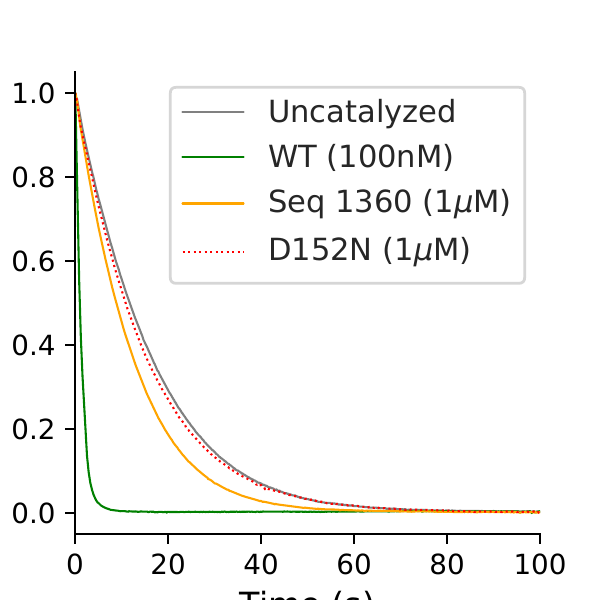

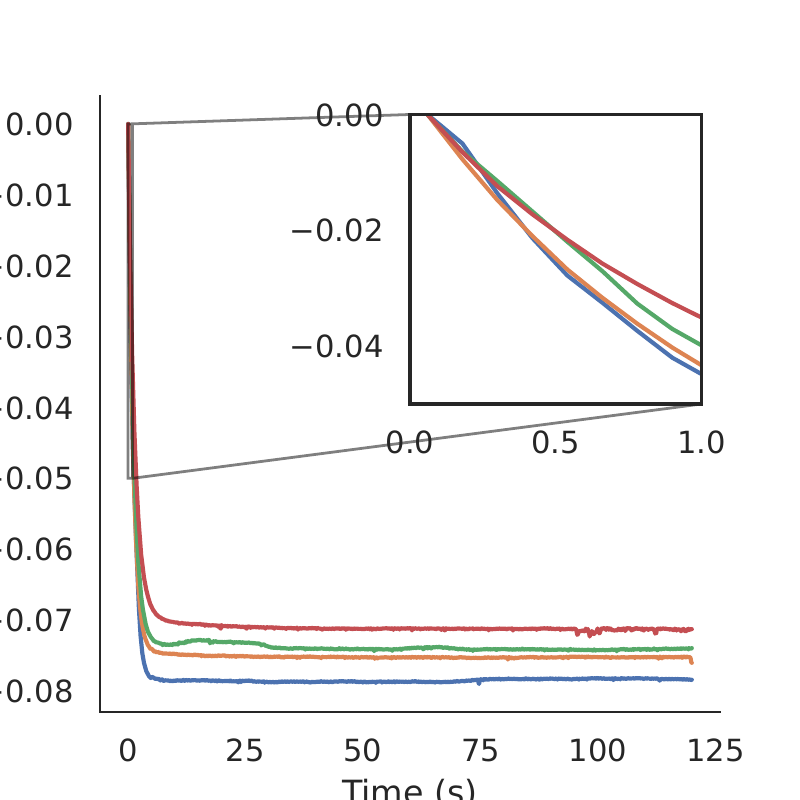

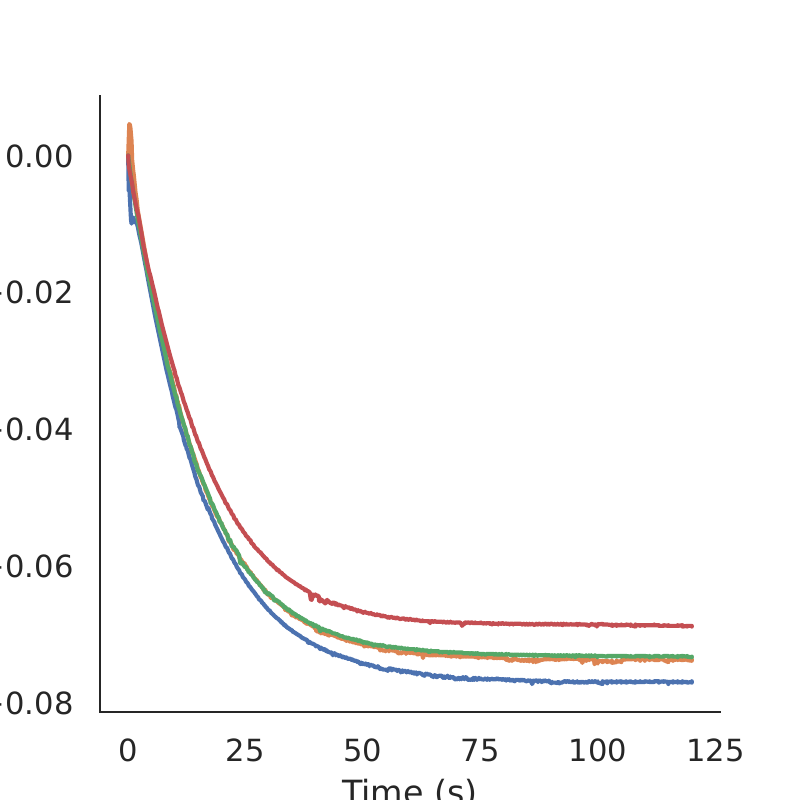

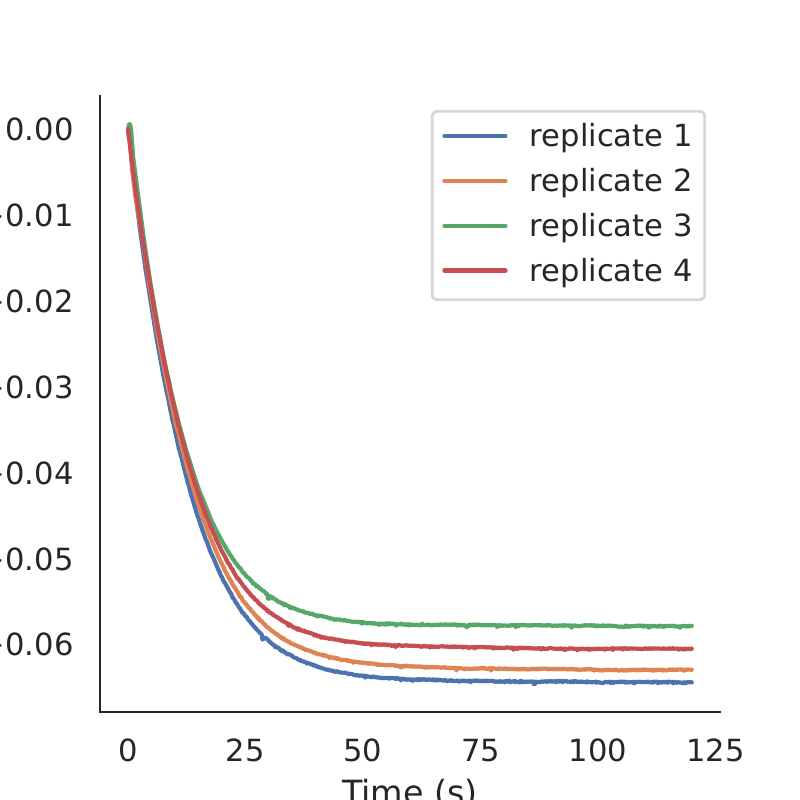

In [6]:
run_nb("in_vitro/stopped_flow_analysis.ipynb")
show_ca("in_vitro/endpoints_figure.pdf", "in_vitro/wt_traces.pdf",
        "in_vitro/d152n_traces.pdf", "in_vitro/1360_traces.pdf")

## 4f — natural kcat distribution across carbonic anhydrases

$ scripts.run_notebook figures/carbonic_anhydrase_figure/computational/Brenda_CA.ipynb


=== cell 1 ===
=== cell 2 ===
57
=== cell 3 ===
notebook complete (failed cells: none)


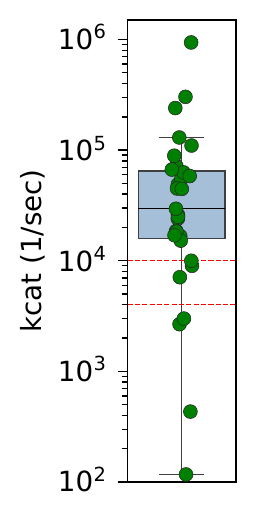

In [7]:
run_nb("computational/Brenda_CA.ipynb")
show_ca("computational/Brenda_CA.pdf")